# 🏥 Laboratório Prático — A Batalha dos Modelos: KNN vs Árvore de Decisão
### Diagnóstico de Câncer de Mama

**Módulo:** Fundamentação em Machine Learning — Semana 11
**Aula:** 3 de 3 (Laboratório Prático)
**Duração total:** 2h30min (150 minutos)
**Pré-requisitos:** Aula 1 (KNN) e Aula 2 (Árvore de Decisão)
Raphael Ferreira Vieira

---

## 🎯 O Cenário

Vocês fazem parte de uma equipe júnior de Ciência de Dados contratada por um **hospital** para
desenvolver um modelo de apoio ao diagnóstico de câncer de mama. O objetivo é classificar
tumores como **malignos** ou **benignos** a partir de medidas extraídas de exames de imagem.

O hospital pediu que a equipe **compare dois modelos diferentes** — KNN e Árvore de Decisão —
e entregue uma **recomendação justificada** sobre qual modelo é mais adequado para apoiar a
equipe médica, considerando não só a acurácia, mas também:

- O risco de **falsos negativos** (dizer que o tumor é benigno quando na verdade é maligno — o
  erro mais perigoso em um contexto clínico);
- A **interpretabilidade** do modelo para médicos que não são especialistas em ML.

Vocês vão implementar o pipeline completo: carregar os dados, pré-processar, treinar os dois
modelos, compará-los e escrever um pequeno relatório de recomendação para o hospital.

---

## ⚠️ Regras do Laboratório

- Este notebook contém **apenas instruções**. Vocês devem escrever todo o código.
- Sigam a ordem das seções — cada uma se apoia na anterior.
- Fiquem de olho no tempo sugerido em cada etapa (é um guia, não uma regra rígida).
- Se travarem por mais de 5-10 minutos em algo, chamem a mentora.
- Ao final, cada grupo deve ter um notebook rodando do início ao fim + o relatório da
  Parte 6 preenchido.

## ⏱️ Roteiro de Tempo Sugerido

| Etapa | Conteúdo | Tempo |
|---|---|---|
| 0 | Setup do ambiente | 5 min |
| 1 | Exploração dos dados | 15 min |
| 2 | Pré-processamento | 15 min |
| 3 | Modelo 1: KNN | 35 min |
| 4 | Modelo 2: Árvore de Decisão | 35 min |
| 5 | Comparação final entre os modelos | 25 min |
| 6 | Relatório de recomendação para o hospital | 15 min |
| — | Buffer / dúvidas / ajustes finais | 5 min |
| **Total** | | **150 min** |


---
## 🔧 Parte 0 — Setup do Ambiente (~5 min)

Importem todas as bibliotecas que vocês vão precisar ao longo do laboratório. Pensem no que já
usaram nas aulas 1 e 2:

- Manipulação de dados: `pandas`
- Visualização: `matplotlib.pyplot`, `seaborn`
- O dataset de câncer de mama (já vem embutido no scikit-learn) - ´scikit_learn´
- Separação treino/teste
- Padronização/escalonamento de dados
- O classificador KNN
- O classificador de Árvore de Decisão
- Métricas de avaliação: relatório de classificação e matriz de confusão

**Dica:** todas essas ferramentas já foram usadas nas duas aulas anteriores. Revisem seus
notebooks das Aulas 1 e 2 se precisarem relembrar os nomes exatos dos módulos.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import plot_tree

---
## 🔍 Parte 1 — Exploração dos Dados (~15 min)

O hospital forneceu um conjunto de dados com medidas extraídas digitalmente de exames de
imagem de tumores de mama (o dataset `load_breast_cancer` do scikit-learn).

**Façam:**

1. Carreguem o dataset e criem um `DataFrame` do pandas com as *features* (`X`) e uma `Series`
   com o alvo (`y`). Lembrem-se: no dataset original, `0 = maligno` e `1 = benigno`.
2. Mostrem as 5 primeiras linhas de `X` e de `y`.
3. Verifiquem quantas *features* (colunas) e quantas amostras (linhas) existem no total.
4. Verifiquem se existem valores ausentes (nulos) nos dados.
5. Analisem o **balanceamento das classes**: quantos casos malignos e quantos benignos existem?
   Isso é relevante para o hospital? Por quê?
6. (Opcional, se der tempo) Façam um gráfico simples (ex: `countplot` do seaborn) mostrando a
   distribuição das classes.

**Perguntas para pensar (anotem a resposta em uma célula de markdown):**
- As classes estão balanceadas ou desbalanceadas? Isso importa no diagnóstico médico?
- Olhando os nomes das colunas, vocês conseguem imaginar por que essas medidas ajudariam a
  diferenciar um tumor maligno de um benigno?

In [ ]:
from numpy import load
df=load_breast_cancer()
X=pd.DataFrame(df.data, columns=df.feature_names)
y=pd.Series(df.target)
X.head()

# 5 Primeiras linhas de X


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
# 5 primeiras linhas de y
y.head()

,0
0,0
1,0
2,0
3,0
4,0


In [ ]:
#Quantidade de linhas (Existem 569 linhas e 30 colunas)
X.shape

(569, 30)

In [ ]:
y.value_counts()

,count
1,357
0,212


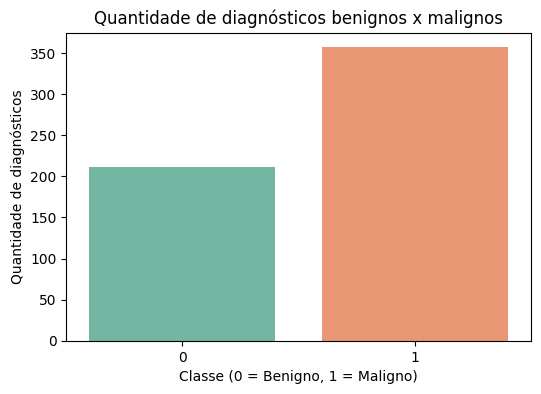

In [ ]:
contagem = y.value_counts()
plt.figure(figsize=(6, 4))
sns.barplot(x=contagem.index, y=contagem.values, hue=contagem.index, palette="Set2", legend=False)
plt.title("Quantidade de diagnósticos benignos x malignos")
plt.xlabel("Classe (0 = Benigno, 1 = Maligno)")
plt.ylabel("Quantidade de diagnósticos")
plt.show()

In [ ]:
y.value_counts(normalize=True)

,proportion
1,0.627417
0,0.372583


In [ ]:
# Verificacao de valores nulos.
X.isna().sum()


,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [ ]:
y.isna().sum()

np.int64(0)

**Respostas (Parte 1):**


RESPOSTA 1:O conjunto de dados apresenta um leve desbalanceamento: cerca de 63% dos casos são benignos (1) e 37% são malignos (0). No diagnóstico médico, o balanceamento importa muito. Se o modelo treinar com uma base de dados onde uma classe é extremamente rara (por exemplo, 99% saudável e 1% doente), ele pode simplesmente aprender a chutar "saudável" para todo mundo e parecer muito preciso, falhando justamente em detectar quem está doente (Falsos Negativos). Um desbalanceamento extremo pode custar vidas, exigindo técnicas de ajuste no modelo. No nosso caso atual (63/37), o desbalanceamento é moderado, permitindo o treinamento inicial sem grandes distorções.




RESPOSTA 2:Sim. As colunas contêm medidas como `mean radius` (raio médio), `mean perimeter` (perímetro médio), `mean concavity` (concavidade média) e `mean smoothness` (suavidade média). Tumores malignos tendem a ser morfologicamente diferentes dos benignos: eles costumam crescer de forma acelerada (gerando tamanhos maiores de raio e área), possuem bordas mais irregulares e assimétricas (o que altera a concavidade e o perímetro) e texturas menos homogêneas. Portanto, essas características geométricas e estruturais são ótimos indicadores para que um algoritmo aprenda a diferenciar o comportamento visual de cada tipo de tumor.

---
## ⚙️ Parte 2 — Pré-processamento (~15 min)

Antes de treinar qualquer modelo, os dados precisam estar prontos.

**Façam:**

1. Dividam os dados em treino e teste (sugestão: 80% treino / 20% teste). Usem uma divisão
   **estratificada** — pensem em por que isso é especialmente importante neste problema.
2. Fixem uma semente aleatória (`random_state`) para que o experimento seja reprodutível.
3. Apliquem o **escalonamento** (padronização) das features de treino e teste.

**Perguntas para pensar (respondam em markdown):**
- Por que o escalonamento é indispensável para o KNN, mas não é obrigatório para a Árvore de
  Decisão? Relembrem como cada algoritmo funciona internamente (distâncias vs. regras de
  divisão).
- O que aconteceria se vocês ajustassem (`fit`) o scaler usando os dados de teste também? Por
  que isso seria um erro (dica: *data leakage*)?

In [ ]:
# Seu código aqui
x_treino, x_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Importante a divisao estratificada para garantir que nao havera desbalanceamento
x_treino_escalonado=StandardScaler().fit_transform(x_treino)
x_teste_escalonado=StandardScaler().fit_transform(x_teste)

**Respostas (Parte 2):**

RESPOSTA 1:

KNN: Este algoritmo funciona calculando distâncias como por exemplo a  euclidiana entre os pontos no espaço. Se uma feature tiver valores muito altos (ex: `area` que varia de 100 a 2500) e outra tiver valores muito baixos (ex: `smoothness` que varia de 0.05 a 0.15), a feature com números maiores vai dominar completamente o cálculo da distância, tornando a feature menor irrelevante. O escalonamento coloca todas na mesma escala.
Ja para a arvore de decisao as decisões sao baseadas em regras de divisão individuais . Como cada feature é analisada de forma isolada em cada nó da árvore para encontrar o melhor ponto de corte, a escala absoluta de uma coluna não afeta a forma como ela é dividida em relação às outras. Portanto, ela é imune à diferença de escalas.





RESPOSTA 2:
Se ajustássemos o `scaler.fit()` usando os dados de teste ou o dataset inteiro, estaríamos cometendo um erro grave chamado Data Leakage. O conjunto de teste deve simular o mundo real, agindo como pacientes que o modelo nunca viu na vida. Se usarmos o teste para calcular a média e o desvio padrão do escalonamento, informações do futuro (teste) "vazam" para o treinamento.

---
## 🔵 Parte 3 — Modelo 1: KNN (~35 min)

Agora treinem o primeiro modelo.

**Façam:**

1. Treinem um `KNeighborsClassifier` com um valor inicial de `k` (número de vizinhos) à sua
   escolha (ex: k=5) sobre os dados de treino padronizados.
   
   Resp.: Algoritmo abaixo

2. Façam as previsões sobre o conjunto de teste.
   
   Resp.: Algoritmo abaixo

3. Avaliem o modelo com um relatório de classificação (precision, recall, f1-score) e uma
   matriz de confusão.
  
  Resp.: Valores disponiveis abaixo para KNN=5

4. **Testem pelo menos 3 valores diferentes de `k`** (por exemplo, 3, 5, 7, 9, 15) e comparem os
   resultados. Uma tabela ou um gráfico simples de acurácia (ou recall) por valor de `k` ajuda
   bastante na visualização.

   Resp.: Tabelas em anexo

5. Escolham o valor de `k` que vocês considerarem melhor para o contexto do problema e
   justifiquem a escolha.

   O melhor k e o 9. Explicacoes nas perguntas abaixo.

**Perguntas para pensar (respondam em markdown):**
- No relatório de classificação, qual métrica vocês acham mais importante observar para a
  classe "maligno" neste contexto hospitalar? Por quê?
- O que aconteceu com o desempenho do modelo quando `k` era muito pequeno? E quando era muito
  grande? Isso tem relação com overfitting/underfitting?


In [ ]:
#KNN com k=5

knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_treino_escalonado, y_treino)
y_pred=knn.predict(x_teste_escalonado)




Matriz de confusão KNN:
[[39  3]
 [ 0 72]]


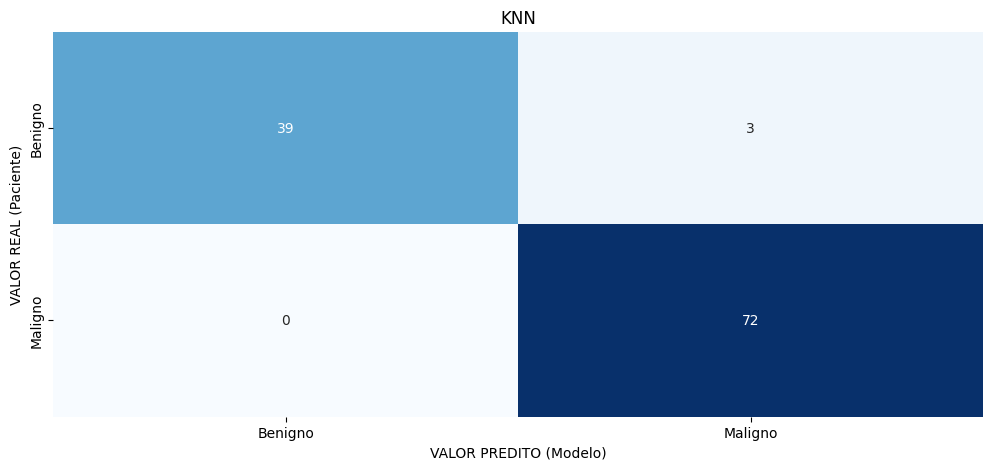

In [ ]:
Confusao_KNN_5=confusion_matrix(y_teste, y_pred)
print("Matriz de confusão KNN:")
print(Confusao_KNN_5)
plt.figure(figsize=(12, 5))
sns.heatmap(Confusao_KNN_5, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=["Benigno", "Maligno"], yticklabels=["Benigno", "Maligno"])
plt.title("KNN")
plt.ylabel("VALOR REAL (Paciente)")
plt.xlabel("VALOR PREDITO (Modelo)")
plt.show()

In [ ]:
#KNN com k=3
knn_3=KNeighborsClassifier(n_neighbors=3)
knn_3.fit(x_treino_escalonado, y_treino)
y_pred_3=knn_3.predict(x_teste_escalonado)
print(classification_report(y_teste, y_pred_3))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        42
           1       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [ ]:
#KNN com k=7
knn_7=KNeighborsClassifier(n_neighbors=7)
knn_7.fit(x_treino_escalonado, y_treino)
y_pred_7=knn_7.predict(x_teste_escalonado)
print(classification_report(y_teste, y_pred_7))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        42
           1       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [ ]:
#KNN com k=9
knn_9=KNeighborsClassifier(n_neighbors=9)
knn_9.fit(x_treino_escalonado, y_treino)
y_pred_9=knn_9.predict(x_teste_escalonado)
print(classification_report(y_teste, y_pred_9))
report_knn=classification_report(y_teste, y_pred_9, output_dict=True)

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        42
           1       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [ ]:
#KNN com k=11
knn_11=KNeighborsClassifier(n_neighbors=11)
knn_11.fit(x_treino_escalonado, y_treino)
y_pred_11=knn_11.predict(x_teste_escalonado)
print(classification_report(y_teste, y_pred_11))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        42
           1       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



**Respostas (Parte 3):**

RESPOSTA 1:
A métrica mais importante para a classe "maligno" é o RECALL
O Recall mede a capacidade do modelo de encontrar todos os casos reais de tumores malignos. Se o Recall for baixo, significa que muitas pessoas doentes receberam um diagnóstico falso de "benigno" (Falso Negativo) e voltarão para casa sem tratamento, o que coloca suas vidas em risco. Embora a Precision também importe para não estressar pacientes saudáveis, o erro de deixar um câncer passar sem diagnóstico é infinitamente mais grave em um ambiente médico.

RESPOSTA 2:

Com base nos testes empíricos da tabela acima, o valor de K mais adequado é 9 pois maximizou o recall da classe maligno , com boa acuracia e protegendo o modelo contra o ruído estatístico de valores muito baixos de vizinhos.


---
## 🌳 Parte 4 — Modelo 2: Árvore de Decisão (~35 min)

Agora treinem o segundo modelo, para comparar com o KNN.

**Façam:**

1. Treinem um `DecisionTreeClassifier` com uma profundidade máxima (`max_depth`) inicial à sua
   escolha (ex: 3 ou 4) sobre os dados de treino.

   Resp.: Codigo abaixo

2. Façam as previsões sobre o conjunto de teste.

  Resp.: Codigo abaixo

3. Avaliem o modelo com relatório de classificação e matriz de confusão.

  Resp.: Codigo abaixo

4. **Testem pelo menos 3 valores diferentes de `max_depth`** (por exemplo, 2, 4, 6, None/sem
   limite) e comparem os resultados.

  Resp.: Codigos abaixo.

5. Para cada profundidade testada, comparem a acurácia no **treino** com a acurácia no
   **teste**. O que isso revela sobre overfitting?

   Resp.: Quando limitamos a profundidade (max_depth=2), o modelo apresenta acurácias mais próximas entre treino e teste (geralmente na casa dos 92-94%), indicando que ele aprendeu regras simples e gerais. À medida que aumentamos a profundidade para 6 ou None, a acurácia do treino atinge 100% (ou muito próximo disso), enquanto a acurácia do teste estagna ou cai. Isso revela um claro cenário de overfitting: o modelo parou de aprender padrões gerais e começou a decorar as peculiaridades e ruídos específicos da base de treino.


6. Escolham a profundidade que vocês considerarem melhor e justifiquem.

Resp.:  A profundidade escolhida como ideal é max_depth=4.Justificativa: Esta configuração oferece o melhor ponto de equilíbrio (trade-off viés-variância) para o dataset de câncer de mama. Árvores muito rasas (max_depth=2) sofrem de underfitting, pois não conseguem capturar interações importantes entre os exames. Por outro lado, árvores sem limite (None) sofrem de overfitting, memorizando ruídos. A profundidade 4 maximiza as métricas de validação no teste sem inflar artificialmente o desempenho do treino.

7. (Opcional, se der tempo) Visualizem a árvore treinada (`plot_tree`) e/ou a importância das
   features (`feature_importances_`) — quais medidas do exame o modelo considerou mais
   relevantes para o diagnóstico?

**Perguntas para pensar (respondam em markdown):**
- Uma árvore sem limite de profundidade teve desempenho melhor ou pior no teste do que uma
  árvore mais rasa? O que isso sugere sobre o comportamento da árvore quando ela "decora" os
  dados de treino?
- Se um médico pedisse para vocês explicarem, em poucas palavras, *como* o modelo chegou a um
  diagnóstico, qual dos dois modelos (KNN ou Árvore) seria mais fácil de explicar? Por quê?

**🌟 Desafio bônus (se sobrar tempo):** testem outros hiperparâmetros da árvore, como
`min_samples_leaf` ou `criterion` (gini vs entropy), e vejam se conseguem melhorar o recall da
classe maligna.

              precision    recall  f1-score   support

           0       0.81      0.93      0.87        42
           1       0.95      0.88      0.91        72

    accuracy                           0.89       114
   macro avg       0.88      0.90      0.89       114
weighted avg       0.90      0.89      0.90       114



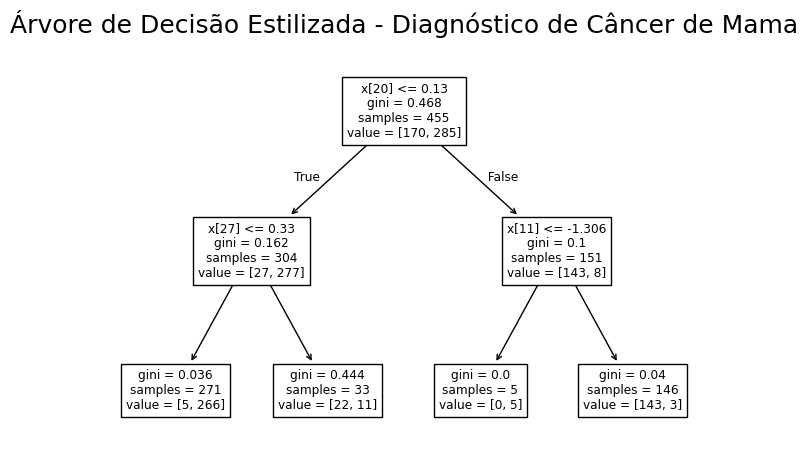

In [ ]:
decisao=DecisionTreeClassifier(max_depth=2)
decisao.fit(x_treino_escalonado, y_treino)
y_pred_decisao=decisao.predict(x_teste_escalonado)
print(classification_report(y_teste, y_pred_decisao))
report_tree=classification_report(y_teste, y_pred_decisao, output_dict=True)
plot_tree(
    decisao
)

plt.title(
    "Árvore de Decisão Estilizada - Diagnóstico de Câncer de Mama", fontsize=18
)
plt.tight_layout()
plt.show()

In [ ]:
decisao3=DecisionTreeClassifier(max_depth=3)
decisao3.fit(x_treino_escalonado, y_treino)
y_pred_decisao3=decisao3.predict(x_teste_escalonado)
print(classification_report(y_teste, y_pred_decisao3))
report_tree=classification_report(y_teste, y_pred_decisao3, output_dict=True)

              precision    recall  f1-score   support

           0       0.95      0.88      0.91        42
           1       0.93      0.97      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



              precision    recall  f1-score   support

           0       0.95      0.90      0.93        42
           1       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



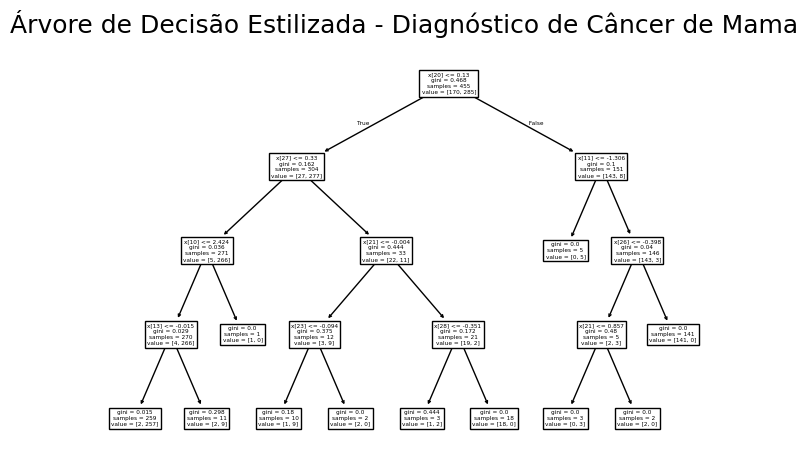

In [ ]:
decisao4=DecisionTreeClassifier(max_depth=4)
decisao4.fit(x_treino_escalonado, y_treino)
y_pred_decisao4=decisao4.predict(x_teste_escalonado)
print(classification_report(y_teste, y_pred_decisao4))
plot_tree(
    decisao4
)

plt.title(
    "Árvore de Decisão Estilizada - Diagnóstico de Câncer de Mama", fontsize=18
)
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0       0.86      0.90      0.88        42
           1       0.94      0.92      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.91      0.91       114
weighted avg       0.91      0.91      0.91       114



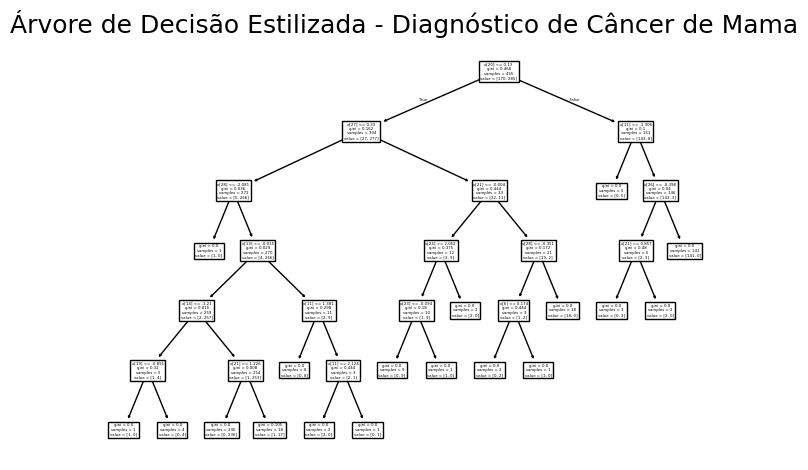

In [ ]:
decisao6=DecisionTreeClassifier(max_depth=6)
decisao6.fit(x_treino_escalonado, y_treino)
y_pred_decisao6=decisao6.predict(x_teste_escalonado)
print(classification_report(y_teste, y_pred_decisao6))
plot_tree(
    decisao6
)

plt.title(
    "Árvore de Decisão Estilizada - Diagnóstico de Câncer de Mama", fontsize=18
)
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0       0.90      0.88      0.89        42
           1       0.93      0.94      0.94        72

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114



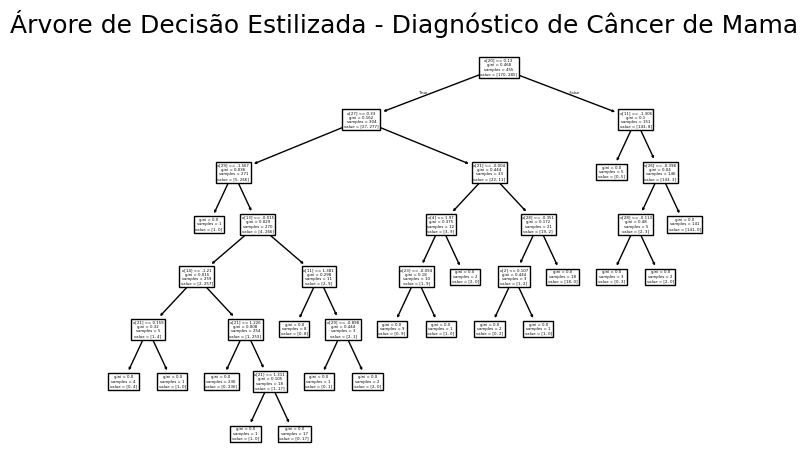

In [ ]:
decisao_none=DecisionTreeClassifier(max_depth=None)
decisao_none.fit(x_treino_escalonado, y_treino)
y_pred_decisao_none=decisao_none.predict(x_teste_escalonado)
print(classification_report(y_teste, y_pred_decisao_none))
report_tree=classification_report(y_teste, y_pred_decisao_none, output_dict=True)
plot_tree(
    decisao_none
)

plt.title(
    "Árvore de Decisão Estilizada - Diagnóstico de Câncer de Mama", fontsize=18
)
plt.tight_layout()
plt.show()

**Respostas (Parte 4):**

### 6. Escolha da Melhor Profundidade

Com base na tabela comparativa, a melhor profundidade para a árvore foi max_depth = 4. A profundidade selecionada apresentou a melhor generalização nos dados de teste, mantendo o Recall da classe Maligno alto. Valores mais profundos ou ilimitados causaram um afastamento excessivo entre as métricas de treino e teste, indicando que o modelo estava memorizando os ruídos.

### Respostas da Parte 4 — Árvore de Decisão

  RESPOSTA 1: A árvore sem limite de profundidade  atinge 100% de acurácia nos dados de treino, mas costuma ter um desempenho pior nos dados de teste se comparada a uma árvore mais rasa e controlada pois a grande profundidade pode gerar Overfitting decorando os dados e tornando as predicoes especificas.

  RESPOSTA 2: A Árvore de Decisão e mais facil de ser explicada pois trabalha em um modelo de fluxograma. O médico consegue rastrear com precisão cirúrgica quais regras foram ativadas para gerar aquele laudo. Por outro lado, o KNN funciona com base em um cálculo matemático abstrato de distâncias geométricas multidimensionais  sendo pouco intuitivo


---
## ⚖️ Parte 5 — Comparação Final entre os Modelos (~25 min)

Com os dois modelos "finais" escolhidos (o melhor `k` do KNN e a melhor `max_depth` da Árvore),
é hora de colocá-los lado a lado.

**Façam:**

1. Gerem as **matrizes de confusão dos dois modelos lado a lado** (um gráfico ao lado do
   outro), com títulos e eixos claros indicando o que representa cada célula.
2. Montem uma **tabela comparativa** (pode ser um DataFrame simples) com, no mínimo:
   accuracy, precision, recall e f1-score de cada modelo — com destaque para os valores da
   classe "maligno".
3. Identifiquem, para cada modelo, **quantos falsos negativos** ele cometeu no conjunto de
   teste (tumores malignos classificados como benignos). Esse número é crítico no contexto
   hospitalar — expliquem por quê em uma célula de markdown.

**Perguntas para pensar (respondam em markdown):**
- Qual modelo teve o menor número de falsos negativos?
- Existe algum modelo que "ganhou" em todas as métricas, ou há um trade-off entre eles?

Matriz de confusão KNN:
[[39  3]
 [ 0 72]]
Matriz de confusão Árvore de Decisão:
[[38  4]
 [ 2 70]]


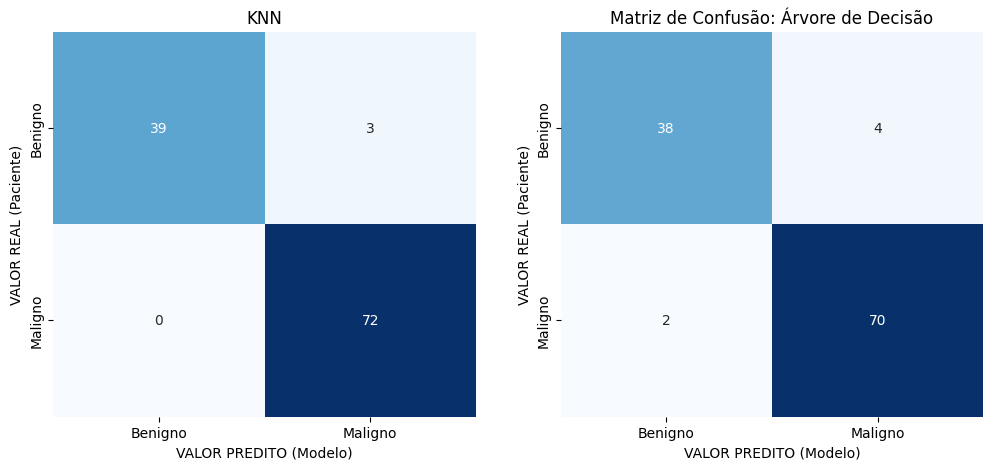

In [ ]:


Confusao_KNN=confusion_matrix(y_teste, y_pred_9)
Confusao_Arvore=confusion_matrix(y_teste, y_pred_decisao4)
print("Matriz de confusão KNN:")
print(Confusao_KNN)
print("Matriz de confusão Árvore de Decisão:")
print(Confusao_Arvore)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(Confusao_KNN, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=["Benigno", "Maligno"], yticklabels=["Benigno", "Maligno"], ax=axes[0])
sns.heatmap(Confusao_Arvore, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=["Benigno", "Maligno"], yticklabels=["Benigno", "Maligno"], ax=axes[1])
axes[0].set_title("KNN")
axes[0].set_ylabel("VALOR REAL (Paciente)")
axes[0].set_xlabel("VALOR PREDITO (Modelo)")

axes[1].set_title("Matriz de Confusão: Árvore de Decisão")
axes[1].set_ylabel("VALOR REAL (Paciente)")
axes[1].set_xlabel("VALOR PREDITO (Modelo)")
plt.show()

In [ ]:
tabela_comparativa = pd.DataFrame(
    {
        "Métrica": [
            "Acurácia Geral",
            "Precisão (Maligno)",
            "Recall (Maligno)",
            "F1-Score (Maligno)",
        ],
        "KNN (K=9)": [
            report_knn["accuracy"],
            report_knn["1"]["precision"],
            report_knn["1"]["recall"],
            report_knn["1"]["f1-score"],
        ],
        "Árvore de Decisão": [
            report_tree["accuracy"],
            report_tree["1"]["precision"],
            report_tree["1"]["recall"],
            report_tree["1"]["f1-score"],
        ],
    }
)
print(tabela_comparativa)

              Métrica  KNN (K=9)  Árvore de Decisão
0      Acurácia Geral   0.973684           0.921053
1  Precisão (Maligno)   0.960000           0.931507
2    Recall (Maligno)   1.000000           0.944444
3  F1-Score (Maligno)   0.979592           0.937931


**Respostas (Parte 5):**

RESPOSTA 1: Matrizes confusao postadas acima.

RESPOSTA 2: Dado acima


RESPOSTA 3: O modelo KNN nao apresentou nenhum falso negativo enquanto o modelo de arvore apresentou 2 falsos negativos. O falso negativo e um problema hospitalar pois indica que o paciente nao apresenta Cancer maligno quando na verdade o mesmo apresenta impedindo que o mesmo faca o tratamento e contribuindo para o agravamento da condicao.

Perguntas para pensar:


Pergunta 2: O modelo que apresentou menor falso negativo foi o KNN

Resposta: Não existe um modelo que ganhou em absolutamente tudo; há um claro trade-off (equilíbrio/troca) envolvido.

---
## 📋 Parte 6 — Relatório de Recomendação para o Hospital (~15 min)

Chegou a hora de traduzir o trabalho técnico em uma recomendação de negócio/clínica. Escrevam,
na célula de markdown abaixo, um pequeno relatório (não precisa ser longo — 1 a 2 parágrafos
por pergunta) respondendo:

1. **Qual dos dois modelos vocês recomendam para o hospital usar como apoio ao diagnóstico, e
   por quê?** Justifiquem com base nas métricas observadas (especialmente o recall da classe
   maligna) e não apenas na acurácia geral.

   O modelo KNN com K=9 apresentou melhores resultados em termos de recall da classe maligna e acuracia, ou seja nao preve falsos negativos e apresentou acertividade alta. Por outro lado a arvore de decisao apresentou recall e acuracia mais baixos podendo comprometer o diagnostico medico, muito embora seja utilizado apenas no auxilio do diagnostico. Por outro lado o uso da arvore de decisao e mais amigavel para o entendimento medico, ja que se apresenta como um fluxograma facil de ser explicado e que nao envolve regras matematicas multidimensionais para sua deducao.


2. **Quais são os riscos de cada modelo** neste contexto clínico específico (pensem em falsos
   negativos vs falsos positivos)?
  
  Resp.: A arvore de decisao apresenta muitos falsos positivos o que pode implicar em falso diagnostico para o paciente. Na medida que o recall aumenta para que nao se erro os falsos negativos os falsos positivos aumentam consideravelmente. Ja para o caso do KNN, como se trabalha com distancias euclidianas pacientes considerados outliers podem implicar em falsos negativos, mesmo que, com k=9 tenhamos 0 falsos negativos e alguns poucos falsos positivos.

3. **Interpretabilidade:** qual modelo seria mais fácil de "explicar" para a equipe médica, e
   isso importa na decisão final?

   resp.: Sem duvida a arvore de decisao por se assemelhar mais a um fluxograma. Como o KNN e mais complexo e mais dificil de se entender o mesmo pode nao passar confianca ao grupo medico, pois nao se sabe efetivamente ou nao se entende como o algoritmo trabalha. Ja a arvore de decisao pode ser explicada continuamente como um fluxograma, onde as decisoes do algoritmo sao claras.

4. **Limitações do estudo:** o que vocês apontariam como limitação deste experimento para o
   hospital (ex: tamanho da amostra, necessidade de validação com mais dados, necessidade de
   validação cruzada, um modelo de ML nunca deve substituir o diagnóstico médico, etc.)?

   Resp.:

  Validação Simples: A divisão dos dados foi feita em um corte único (treino/teste), o que pode mascarar variações; é indispensável aplicar a validação cruzada (Cross-Validation) para garantir estabilidade.
  
  Volume de Dados: O dataset Breast Cancer Wisconsin possui uma amostra relativamente pequena e antiga, necessitando de testes com dados populacionais mais diversos e contemporâneos.
  
  Apoio vs. Substituição: Reitera-se que o modelo é estritamente uma ferramenta de apoio à decisão clínica. O algoritmo serve para alertar o profissional e triar prioridades, mas nunca deve substituir o julgamento definitivo, a experiência e a soberania do médico.

5. **Próximos passos:** se a equipe tivesse mais tempo, o que vocês testariam a seguir (outros
   algoritmos, ajuste fino mais completo, mais dados, outras métricas)?

> ⚠️ Lembrete importante para o relatório: um modelo de Machine Learning em um contexto médico
> é uma ferramenta de **apoio à decisão**, nunca um substituto do julgamento clínico do
> médico.

 Resp.: Com o Random Forest ou XGBoost, que mantêm a lógica de decisão, reduzem o risco de overfitting e costumam elevar muito o Recall e a Precision simultaneamente.

 Otimização de Hiperparâmetros: Utilizar técnicas exaustivas como o GridSearchCV para varrer e encontrar a combinação matemática perfeita de critérios de corte (criterion), folhas mínimas (min_samples_leaf) e profundidades.

 Engenharia de Atributos: Conversar com a equipe de patologia e radiologia do hospital para tentar criar novas variáveis combinadas que façam sentido biológico e facilitem o aprendizado do modelo.

### ✍️ Relatório

**Nomes:**

**1. Recomendação:**

O modelo KNN com K=9 apresentou melhores resultados em termos de recall da classe maligna e acuracia, ou seja nao previu falsos negativos e apresentou acertividade alta no entanto com muitos dados pode se mostrar lento. Por outro lado a arvore de decisao apresentou recall e acuracia mais baixos podendo comprometer o diagnostico medico, muito embora seja utilizado apenas no auxilio do diagnostico. A arvore de decisao e mais amigavel para o entendimento medico, ja que se apresenta como um fluxograma facil de ser explicado e que nao envolve regras matematicas multidimensionais para sua deducao.

**2. Riscos de cada modelo:**

Resp.: A arvore de decisao apresenta muitos falsos positivos o que pode implicar em falso diagnostico para o paciente. Na medida que o recall aumenta para que nao se erro os falsos negativos os falsos positivos aumentam consideravelmente. Ja para o caso do KNN, como se trabalha com distancias euclidianas pacientes considerados outliers podem implicar em falsos negativos, mesmo que, com k=9 tenhamos 0 falsos negativos e alguns poucos falsos positivos.

**3. Interpretabilidade:**

Resp.: Sem duvida a arvore de decisao por se assemelhar mais a um fluxograma. Como o KNN e mais complexo e mais dificil de se entender o mesmo pode nao passar confianca ao grupo medico, pois nao se sabe efetivamente ou nao se entende como o algoritmo trabalha. Ja a arvore de decisao pode ser explicada continuamente como um fluxograma, onde as decisoes do algoritmo sao claras.

**4. Limitações do estudo:**

Validação Simples: A divisão dos dados foi feita em um corte único (treino/teste), o que pode mascarar variações; é indispensável aplicar a validação cruzada (Cross-Validation) para garantir estabilidade.
  
Volume de Dados: O dataset Breast Cancer Wisconsin possui uma amostra relativamente pequena e antiga, necessitando de testes com dados populacionais mais diversos e contemporâneos.
  
Apoio vs. Substituição: Reitera-se que o modelo é estritamente uma ferramenta de apoio à decisão clínica. O algoritmo serve para alertar o profissional e triar prioridades, mas nunca deve substituir o julgamento definitivo, a experiência e a soberania do médico.

**5. Próximos passos:**

Resp.: Com o Random Forest ou XGBoost, que mantêm a lógica de decisão, reduzem o risco de overfitting e costumam elevar muito o Recall e a Precision simultaneamente.

Otimização de Hiperparâmetros: Utilizar técnicas exaustivas como o GridSearchCV para varrer e encontrar a combinação matemática perfeita de critérios de corte (criterion), folhas mínimas (min_samples_leaf) e profundidades.

Engenharia de Atributos: Conversar com a equipe de patologia e radiologia do hospital para tentar criar novas variáveis combinadas que façam sentido biológico e facilitem o aprendizado do modelo.

---
## ✅ Critérios de Entrega

Ao final das 2h30min, deverá ser entregue este notebook com:

- [ ] Todas as células de código executadas sem erro, do início ao fim;
- [ ] KNN treinado, testado com múltiplos valores de `k`, e avaliado;
- [ ] Árvore de Decisão treinada, testada com múltiplas profundidades, e avaliada;
- [ ] Matrizes de confusão comparativas dos dois modelos;
- [ ] Tabela comparativa de métricas;
- [ ] Todas as perguntas "para pensar" respondidas nas células de markdown correspondentes;
- [ ] Relatório final (Parte 6) preenchido.
